In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Carregar dados do Censo Escolar 2023
df = pd.read_csv('../data/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv', encoding='latin-1', sep=';')
df.head()

/tmp/ipykernel_37782/1936111666.py:5: DtypeWarning: Columns (0: CO_ORGAO_REGIONAL) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/microdados_censo_escolar_2023/dados/microdados_ed_basica_2023.csv', encoding='latin-1', sep=';')


,NU_ANO_CENSO,NO_REGIAO,CO_REGIAO,NO_UF,SG_UF,CO_UF,NO_MUNICIPIO,CO_MUNICIPIO,NO_REGIAO_GEOG_INTERM,CO_REGIAO_GEOG_INTERM,...,QT_TUR_BAS_D,QT_TUR_BAS_N,QT_TUR_BAS_EAD,QT_TUR_INF_INT,QT_TUR_INF_CRE_INT,QT_TUR_INF_PRE_INT,QT_TUR_FUND_INT,QT_TUR_FUND_AI_INT,QT_TUR_FUND_AF_INT,QT_TUR_MED_INT
0,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,14.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,38.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2023,Norte,1,Rondônia,RO,11,Porto Velho,1100205,Porto Velho,1101,...,27.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


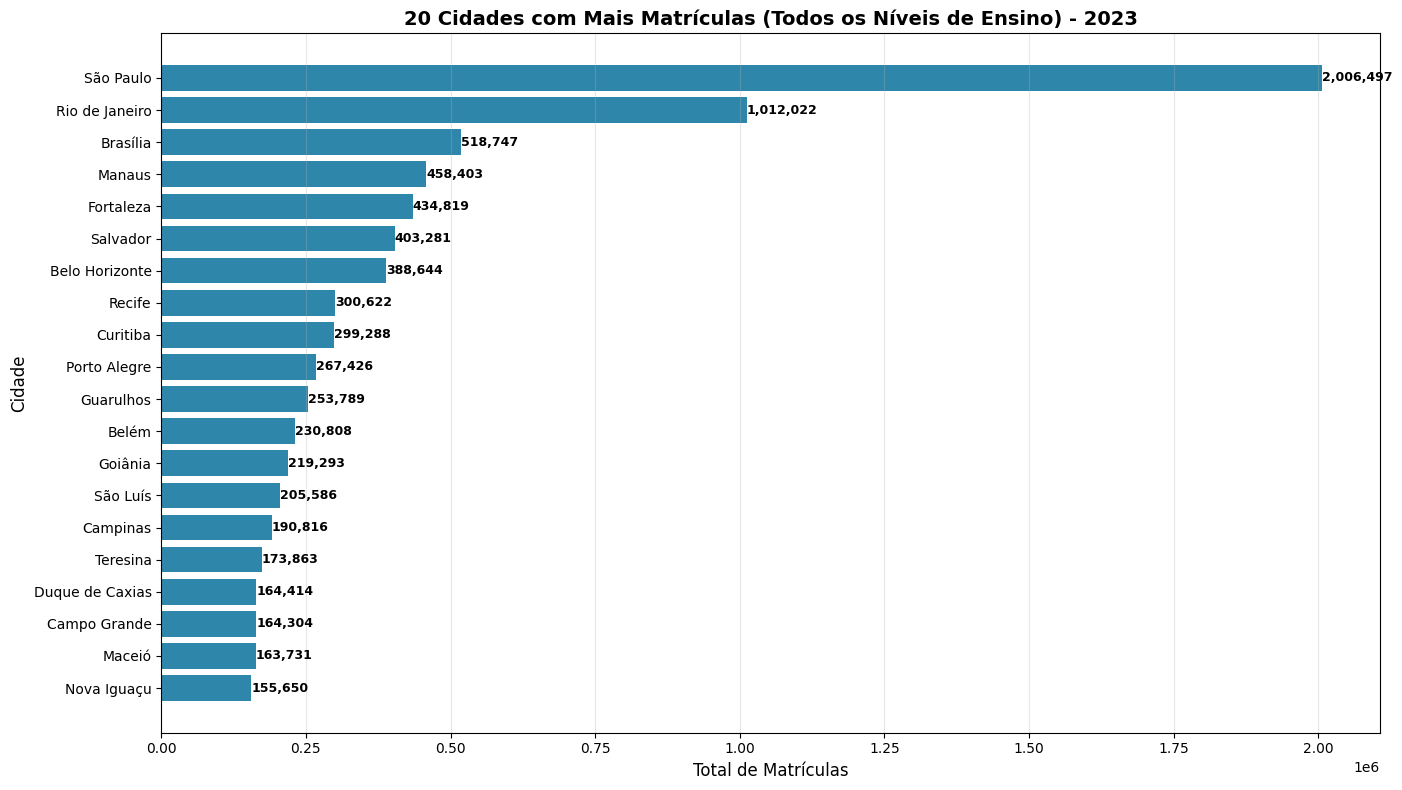

In [2]:
# Colunas de matrículas por nível
colunas_matriculas = [
    'QT_MAT_FUND_AI',      # Fundamental anos iniciais
    'QT_MAT_FUND_AF',      # Fundamental anos finais
    'QT_MAT_MED',          # Ensino médio
    'QT_MAT_PROF',         # Ensino profissionalizante
    'QT_MAT_EJA_MED'       # EJA ensino médio
]

# Agrupar por município e somar as matrículas
alunos_por_municipio = df.groupby(['NO_MUNICIPIO', 'CO_MUNICIPIO'])[colunas_matriculas].sum()

# Calcular o total de matrículas por município
alunos_por_municipio['Total'] = alunos_por_municipio.sum(axis=1)

# Obter as 20 cidades com mais matrículas
top_20_cidades = alunos_por_municipio.nlargest(20, 'Total').reset_index()

# Criar gráfico
plt.figure(figsize=(14, 8))
bars = plt.barh(top_20_cidades['NO_MUNICIPIO'], top_20_cidades['Total'], color='#2E86AB')

plt.title('20 Cidades com Mais Matrículas (Todos os Níveis de Ensino) - 2023', fontsize=14, fontweight='bold')
plt.xlabel('Total de Matrículas', fontsize=12)
plt.ylabel('Cidade', fontsize=12)
plt.gca().invert_yaxis()  # Mostrar a maior barra no topo
plt.tight_layout()
plt.grid(axis='x', alpha=0.3)

# Adicionar labels com o valor total
for i, (cidade, total) in enumerate(zip(top_20_cidades['NO_MUNICIPIO'], top_20_cidades['Total'])):
    plt.text(total, i, f'{int(total):,}', va='center', ha='left', fontsize=9, fontweight='bold')

plt.show()